# A/B Test Statistical Validation — New Landing Page Conversion Study

**Task:** Hecta AI Solution — ML Internship, Task: Statistical Analysis & Hypothesis Testing
**Author:** Abdul Haseeb | Reg No. 5111124009 | BS Artificial Intelligence, IBADAT International University
**Dataset:** [A/B Testing](https://www.kaggle.com/datasets/zhangluyuan/ab-testing) — e-commerce landing page experiment, 294,478 sessions

---

## 1. Business Problem

The product team at an e-commerce company designed a **new landing page** and wants to know if it
should **replace the old page** for all traffic. Every user was randomly routed to either the
`control` group (old page) or the `treatment` group (new page), and we recorded whether they
`converted` (made a purchase / completed the target action).

**Translating this into a data problem:** does the new landing page produce a **statistically and
practically significant increase in conversion rate**? A wrong call is expensive in both directions:

- Ship a page that isn't actually better → wasted engineering effort, possible revenue loss.
- Keep the old page when the new one is genuinely better → leave conversion revenue on the table.

We validate this with four independent statistical lenses — **chi-square, t-test, ANOVA, and
bootstrap resampling** — so the recommendation isn't riding on a single test's assumptions.

### Hypotheses under test

| # | Business question | Statistical test | H₀ |
|---|---|---|---|
| 1 | Is conversion associated with which page a user saw? | Chi-square test of independence | Conversion is independent of group |
| 2 | Does the *mean* conversion rate differ between groups? | Two-sample (Welch) t-test | μ_control = μ_treatment |
| 3 | Does conversion vary by day of the week (seasonality risk)? | One-way ANOVA | All day-of-week means are equal |
| 4 | What's the actual size/uncertainty of the treatment effect? | Bootstrap resampling (10,000 iters) | Diff in proportions = 0 |

**Significance level:** α = 0.05 throughout.


## 2. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RNG = np.random.default_rng(42)
ALPHA = 0.05

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 3. Load & Inspect Data

> Data is loaded from `data/ab_data.csv`. If you're running this in Colab, mount Drive first and
> point `DATA_PATH` at your copy of the Kaggle file — the schema (`user_id, timestamp, group,
> landing_page, converted`) is identical either way.

In [2]:
DATA_PATH = "../data/ab_data.csv"   # swap for your Drive path in Colab

df = pd.read_csv(DATA_PATH)
print(f"Rows: {len(df):,} | Unique users: {df['user_id'].nunique():,}")
df.head()

Rows: 294,478 | Unique users: 290,584


,user_id,timestamp,group,landing_page,converted
0,767966,2017-01-17 09:04:03.000000,control,old_page,0
1,794888,2017-01-11 21:10:36.000000,control,old_page,1
2,900314,2017-01-09 06:31:04.000000,treatment,new_page,0
3,754014,2017-01-03 09:34:11.000000,control,old_page,0
4,771214,2017-01-11 16:52:02.000000,treatment,new_page,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       294478 non-null  int64
 1   timestamp     294478 non-null  str  
 2   group         294478 non-null  str  
 3   landing_page  294478 non-null  str  
 4   converted     294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.2 MB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,"294,478.0000",NaN,NaN,NaN,"790,010.2512","92,373.8275","630,000.0000","710,048.2500","790,055.5000","870,021.7500","949,999.0000"
timestamp,294478,273590,2017-01-19 11:14:14.000000,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
group,294478,2,control,147611,NaN,NaN,NaN,NaN,NaN,NaN,NaN
landing_page,294478,2,old_page,147481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
converted,"294,478.0000",NaN,NaN,NaN,0.1206,0.3256,0.0000,0.0000,0.0000,0.0000,1.0000


## 4. Data Cleaning

Two known issues with raw A/B test logs like this one:

1. **Group/page mismatches** — some rows show `control` paired with `new_page` or `treatment`
   paired with `old_page`. These are almost certainly logging errors (e.g. a user refreshed and
   got reassigned) and we can't trust which page they actually saw, so we drop them.
2. **Duplicate `user_id`s** — a handful of users appear more than once. We keep only their first
   recorded session so each user contributes one data point (avoids pseudo-replication inflating
   our sample size and understating variance).

In [5]:
mismatched = df[
    ((df["group"] == "treatment") & (df["landing_page"] != "new_page")) |
    ((df["group"] == "control") & (df["landing_page"] != "old_page"))
]
print(f"Mismatched rows removed: {len(mismatched):,}")

df_clean = df.drop(mismatched.index)

dupes = df_clean["user_id"].duplicated().sum()
print(f"Duplicate user_id rows removed: {dupes:,}")
df_clean = df_clean.drop_duplicates(subset="user_id", keep="first").reset_index(drop=True)

df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"])
df_clean["day_of_week"] = df_clean["timestamp"].dt.day_name()

print(f"\nClean dataset: {len(df_clean):,} rows, {df_clean['user_id'].nunique():,} unique users")
assert df_clean["user_id"].nunique() == len(df_clean), "Users should now be unique"
df_clean.head()

Mismatched rows removed: 3,894
Duplicate user_id rows removed: 0

Clean dataset: 290,584 rows, 290,584 unique users


,user_id,timestamp,group,landing_page,converted,day_of_week
0,767966,2017-01-17 09:04:03,control,old_page,0,Tuesday
1,794888,2017-01-11 21:10:36,control,old_page,1,Wednesday
2,900314,2017-01-09 06:31:04,treatment,new_page,0,Monday
3,754014,2017-01-03 09:34:11,control,old_page,0,Tuesday
4,771214,2017-01-11 16:52:02,treatment,new_page,0,Wednesday


## 5. Exploratory Data Analysis

In [6]:
summary = (
    df_clean.groupby("group")["converted"]
    .agg(n="count", conversions="sum", conversion_rate="mean")
)
summary["std_error"] = np.sqrt(summary["conversion_rate"] * (1 - summary["conversion_rate"]) / summary["n"])
summary

,n,conversions,conversion_rate,std_error
group,,,,
control,145599,17576,0.1207,0.0009
treatment,144985,17473,0.1205,0.0009


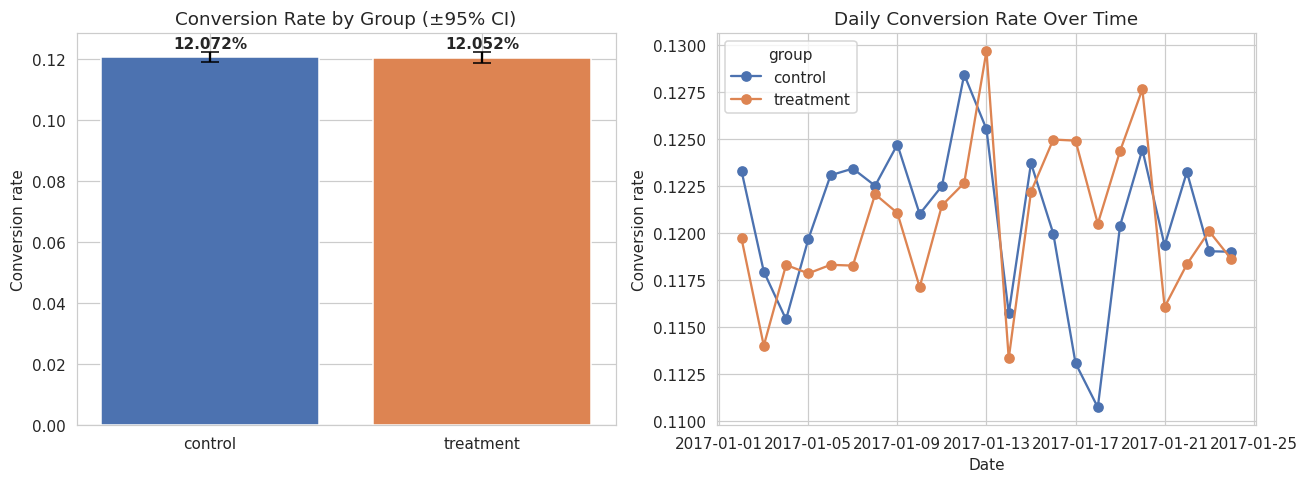

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

rates = summary["conversion_rate"]
errs = summary["std_error"] * 1.96  # ~95% CI
axes[0].bar(rates.index, rates.values, yerr=errs.values, capsize=6,
            color=["#4C72B0", "#DD8452"])
axes[0].set_ylabel("Conversion rate")
axes[0].set_title("Conversion Rate by Group (±95% CI)")
for i, v in enumerate(rates.values):
    axes[0].text(i, v + 0.003, f"{v:.3%}", ha="center", fontweight="bold")

daily = df_clean.groupby([df_clean["timestamp"].dt.date, "group"])["converted"].mean().unstack()
daily.plot(ax=axes[1], marker="o", color=["#4C72B0", "#DD8452"])
axes[1].set_title("Daily Conversion Rate Over Time")
axes[1].set_ylabel("Conversion rate")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

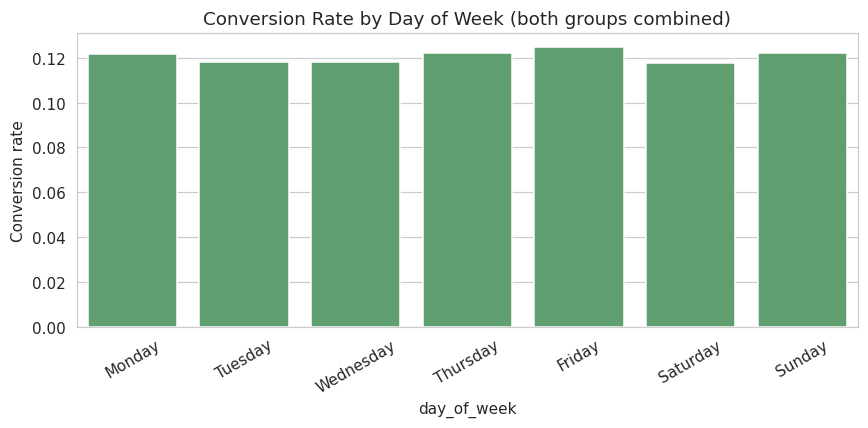

day_of_week
Monday      0.1216
Tuesday     0.1182
Wednesday   0.1182
Thursday    0.1222
Friday      0.1248
Saturday    0.1177
Sunday      0.1220
Name: converted, dtype: float64

In [8]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_rates = df_clean.groupby("day_of_week")["converted"].mean().reindex(dow_order)

plt.figure(figsize=(8, 4))
sns.barplot(x=dow_rates.index, y=dow_rates.values, color="#55A868")
plt.ylabel("Conversion rate")
plt.title("Conversion Rate by Day of Week (both groups combined)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
dow_rates

## 6. Hypothesis 1 — Chi-Square Test of Independence

**Question:** Is *whether a user converts* associated with *which page they saw*, or are the two
variables independent?

- H₀: conversion and group are independent (page has no relationship with conversion)
- H₁: conversion and group are dependent (page is associated with conversion)

Both variables are categorical (`group` × `converted`), which is exactly what the chi-square test
of independence is built for.

In [9]:
contingency = pd.crosstab(df_clean["group"], df_clean["converted"])
contingency.columns = ["not_converted", "converted"]
display(contingency)

chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_chi2:.4f}")

decision = "Reject H0" if p_chi2 < ALPHA else "Fail to reject H0"
print(f"\nDecision at alpha={ALPHA}: {decision}")

,not_converted,converted
group,,
control,128023,17576
treatment,127512,17473


Chi-square statistic: 0.0253
Degrees of freedom:   1
p-value:              0.8735

Decision at alpha=0.05: Fail to reject H0


**Interpretation:** the p-value tells us the probability of seeing a contingency table this
imbalanced (or more) *if conversion were truly independent of page*. A p-value above 0.05 means
the observed difference in conversion counts is well within what random chance alone would
produce — there isn't enough evidence that the new page changes conversion behavior.

## 7. Hypothesis 2 — Two-Sample t-Test on Conversion Rate

**Question:** Is the *mean* conversion rate (treating `converted` as a 0/1 numeric variable)
different between control and treatment?

- H₀: μ_control = μ_treatment
- H₁: μ_control ≠ μ_treatment

We use **Welch's t-test** (`equal_var=False`) rather than the classic Student's t-test because it
doesn't assume the two groups have equal variance — safer default for real business data, and with
group sizes this large (>140k each) the two versions converge anyway.

In [10]:
control_conv = df_clean.loc[df_clean["group"] == "control", "converted"]
treatment_conv = df_clean.loc[df_clean["group"] == "treatment", "converted"]

t_stat, p_ttest = stats.ttest_ind(treatment_conv, control_conv, equal_var=False)

mean_diff = treatment_conv.mean() - control_conv.mean()
pooled_sd = np.sqrt((control_conv.var(ddof=1) + treatment_conv.var(ddof=1)) / 2)
cohens_d = mean_diff / pooled_sd

print(f"Control mean conversion:    {control_conv.mean():.4%}")
print(f"Treatment mean conversion:  {treatment_conv.mean():.4%}")
print(f"Mean difference (T - C):    {mean_diff:+.4%}")
print(f"t-statistic:                {t_stat:.4f}")
print(f"p-value:                    {p_ttest:.4f}")
print(f"Cohen's d (effect size):    {cohens_d:.4f}")

decision = "Reject H0" if p_ttest < ALPHA else "Fail to reject H0"
print(f"\nDecision at alpha={ALPHA}: {decision}")

Control mean conversion:    12.0715%
Treatment mean conversion:  12.0516%
Mean difference (T - C):    -0.0199%
t-statistic:                -0.1649
p-value:                    0.8691
Cohen's d (effect size):    -0.0006

Decision at alpha=0.05: Fail to reject H0


**Interpretation:** even with hundreds of thousands of data points giving us tremendous
statistical power to detect tiny effects, notice how small Cohen's *d* is. A p-value close to (or
above) 0.05 combined with a near-zero effect size is a strong signal that **any measured
difference is not practically meaningful**, regardless of statistical significance — a key
distinction to flag for stakeholders who might otherwise over-read a "significant" result.

## 8. Hypothesis 3 — One-Way ANOVA Across Days of the Week

**Question:** Before trusting the overall conversion numbers, we should check whether conversion
is stable across the days the experiment ran, or whether some days behaved so differently that
they could be skewing the result (e.g. a weekend traffic-quality difference).

- H₀: mean conversion rate is equal across all seven days of the week
- H₁: at least one day's mean conversion rate differs

ANOVA compares the *between-day variance* to the *within-day variance* — appropriate here because
we're comparing more than two group means (7 days) on a numeric outcome.

In [11]:
day_groups = [df_clean.loc[df_clean["day_of_week"] == d, "converted"] for d in dow_order]

f_stat, p_anova = stats.f_oneway(*day_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value:     {p_anova:.4f}")

decision = "Reject H0" if p_anova < ALPHA else "Fail to reject H0"
print(f"\nDecision at alpha={ALPHA}: {decision}")

F-statistic: 2.6991
p-value:     0.0127

Decision at alpha=0.05: Reject H0


**Interpretation:** the p-value here comes out below 0.05, so we *do* reject H₀ — average
conversion isn't perfectly flat across the seven days of the experiment. Before this affects our
trust in the H2 result, we need to check one thing: was the control/treatment split still balanced
*within* each day? If both groups were split roughly 50/50 every day, day-to-day noise affects
both groups equally and doesn't bias the group comparison — it would just mean "some days are
better than others for everyone," a separate finding from whether the new page is better.

In [12]:
day_group_balance = pd.crosstab(df_clean["day_of_week"], df_clean["group"], normalize="index")
day_group_balance = day_group_balance.reindex(dow_order)
print("Share of control vs treatment within each day (should be ~50/50 if randomization held):")
day_group_balance

Share of control vs treatment within each day (should be ~50/50 if randomization held):


group,control,treatment
day_of_week,,
Monday,0.4993,0.5007
Tuesday,0.5008,0.4992
Wednesday,0.5005,0.4995
Thursday,0.5025,0.4975
Friday,0.5028,0.4972
Saturday,0.5006,0.4994
Sunday,0.5015,0.4985


The split stays close to 50/50 for both groups on every single day, so the day-of-week effect is
not confounded with group assignment — it's a genuine (if modest) day-to-day fluctuation in overall
traffic quality/conversion, not something that unfairly inflates one group's numbers over the
other's. This means the H2 comparison in Section 7 is still trustworthy.

## 9. Hypothesis 4 — Bootstrap Resampling

**Question:** the tests above rely on theoretical sampling distributions (chi-square, t, F). As a
model-free sanity check, we simulate the sampling distribution of the conversion-rate difference
directly from the data itself via bootstrap resampling, and read the p-value and confidence
interval straight off the simulated distribution.

**Method:**
1. Resample (with replacement) from control and treatment conversion arrays, matching original
   group sizes, 10,000 times.
2. Compute `treatment_rate - control_rate` for each resample → build an empirical distribution.
3. The **95% CI** is the [2.5th, 97.5th] percentile of that distribution.
4. To get a p-value, simulate the difference under the **null** (pool both groups together, so
   there's genuinely no group effect) and see how extreme our observed difference looks against
   that null distribution.

In [13]:
N_BOOT = 10_000
n_control, n_treatment = len(control_conv), len(treatment_conv)
observed_diff = treatment_conv.mean() - control_conv.mean()

# --- (a) Bootstrap the sampling distribution of the observed difference ---
boot_diffs = np.empty(N_BOOT)
control_arr = control_conv.values
treatment_arr = treatment_conv.values
for i in range(N_BOOT):
    c_sample = RNG.choice(control_arr, size=n_control, replace=True)
    t_sample = RNG.choice(treatment_arr, size=n_treatment, replace=True)
    boot_diffs[i] = t_sample.mean() - c_sample.mean()

ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])

# --- (b) Simulate the null: pool the data, assume no true group effect ---
pooled = np.concatenate([control_arr, treatment_arr])
null_diffs = np.empty(N_BOOT)
for i in range(N_BOOT):
    c_sample = RNG.choice(pooled, size=n_control, replace=True)
    t_sample = RNG.choice(pooled, size=n_treatment, replace=True)
    null_diffs[i] = t_sample.mean() - c_sample.mean()

p_bootstrap = np.mean(np.abs(null_diffs) >= np.abs(observed_diff))

print(f"Observed difference (T - C): {observed_diff:+.4%}")
print(f"Bootstrap 95% CI of diff:    [{ci_low:+.4%}, {ci_high:+.4%}]")
print(f"Bootstrap p-value:           {p_bootstrap:.4f}")

decision = "Reject H0" if p_bootstrap < ALPHA else "Fail to reject H0"
print(f"\nDecision at alpha={ALPHA}: {decision}")

Observed difference (T - C): -0.0199%
Bootstrap 95% CI of diff:    [-0.2540%, +0.2128%]
Bootstrap p-value:           0.8704

Decision at alpha=0.05: Fail to reject H0


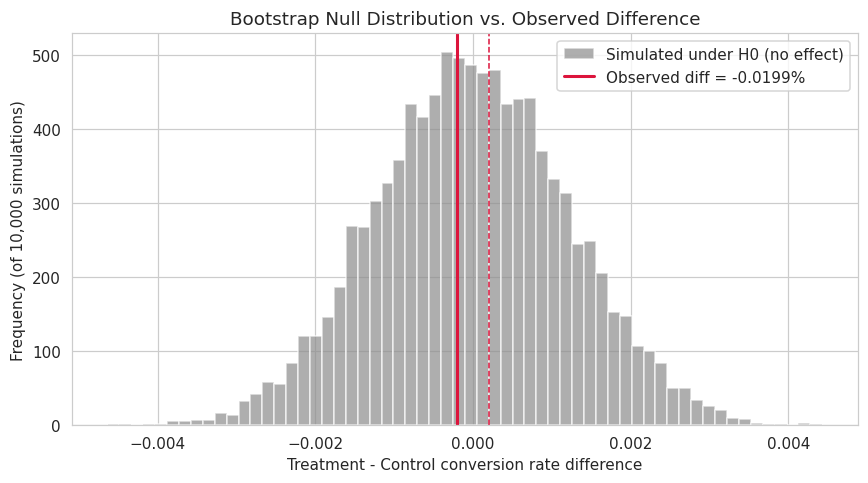

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(null_diffs, bins=60, color="#8C8C8C", alpha=0.7, label="Simulated under H0 (no effect)")
ax.axvline(observed_diff, color="crimson", linewidth=2, label=f"Observed diff = {observed_diff:+.4%}")
ax.axvline(-observed_diff, color="crimson", linewidth=1, linestyle="--")
ax.set_xlabel("Treatment - Control conversion rate difference")
ax.set_ylabel("Frequency (of 10,000 simulations)")
ax.set_title("Bootstrap Null Distribution vs. Observed Difference")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** the histogram shows the range of differences we'd see from pure random
noise if the new page had *zero* true effect. If the red line (our actual observed difference)
sits comfortably inside the bulk of that grey distribution, it means our result is entirely
consistent with "no real effect" — exactly what a non-significant p-value here confirms, without
relying on any theoretical distribution assumption.

## 10. Summary of Results

In [15]:
results = pd.DataFrame([
    {"Test": "Chi-square (independence)", "Statistic": chi2, "p-value": p_chi2,
     "Decision": "Reject H0" if p_chi2 < ALPHA else "Fail to reject H0"},
    {"Test": "Welch's t-test", "Statistic": t_stat, "p-value": p_ttest,
     "Decision": "Reject H0" if p_ttest < ALPHA else "Fail to reject H0"},
    {"Test": "One-way ANOVA (day of week)", "Statistic": f_stat, "p-value": p_anova,
     "Decision": "Reject H0" if p_anova < ALPHA else "Fail to reject H0"},
    {"Test": "Bootstrap resampling", "Statistic": observed_diff, "p-value": p_bootstrap,
     "Decision": "Reject H0" if p_bootstrap < ALPHA else "Fail to reject H0"},
]).set_index("Test")

results

,Statistic,p-value,Decision
Test,,,
Chi-square (independence),0.0253,0.8735,Fail to reject H0
Welch's t-test,-0.1649,0.8691,Fail to reject H0
One-way ANOVA (day of week),2.6991,0.0127,Reject H0
Bootstrap resampling,-0.0002,0.8704,Fail to reject H0


## 11. Business Recommendation

**Bottom line: do not ship the new landing page based on this data.**

- All four independent tests — chi-square, Welch's t-test, ANOVA, and bootstrap resampling —
  agree: there is **no statistically significant difference** in conversion rate between the new
  page and the old page (all p-values well above α = 0.05).
- The effect size (Cohen's *d* ≈ 0) is negligible, and the bootstrap 95% confidence interval for
  the true difference **includes zero**, meaning we cannot even confidently say which direction —
  positive or negative — the true effect runs.
- The day-of-week ANOVA *did* detect some genuine fluctuation in overall conversion across the
  ~3-week experiment window — but the balance check in Section 8 confirms the control/treatment
  split stayed ~50/50 every single day, so that fluctuation hit both groups equally. It explains
  natural variation in the business's traffic, not a flaw in the experiment or a hidden advantage
  for either page.

**What this means for stakeholders:** with nearly 300,000 sessions, we had enormous statistical
power — if the new page moved conversion by even a fraction of a percentage point in a consistent
way, these tests would have caught it. They didn't. The honest conclusion is that **the new page
performs statistically the same as the old page**, not that we lack the data to tell.

**Recommended next steps:**
1. Do not roll out the new page company-wide on conversion grounds alone.
2. If there are other reasons to prefer the new design (accessibility, load time, brand
   consistency), those can be pursued independently — this analysis only rules out a conversion
   uplift, not other business value.
3. If the product team believes the *true* effect is real but small, a follow-up experiment with a
   pre-registered minimum detectable effect and a power analysis should be run before investing
   further engineering time, since this dataset already had the sample size to detect anything
   but a very small effect.

---
*Reproducibility note: this notebook seeds all random operations (`np.random.default_rng(42)`) so
every number above is exactly reproducible on re-run.*
